In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder


In [3]:
df = pd.read_csv('./cmu-sleep (1).csv')
df

,subject_id,study,cohort,demo_race,demo_gender,demo_firstgen,bedtime_mssd,TotalSleepTime,midpoint_sleep,frac_nights_with_data,daytime_sleep,cum_gpa,term_gpa,term_units,Zterm_units_ZofZ
0,185,5,lac1,1,1,0,0.116727,432.200000,458.660000,0.862069,24.160000,3.000000,3.380000,73,4.055294859
1,158,5,lac1,0,1,0,0.141681,391.931035,364.465517,1.000000,13.137931,3.660000,2.600000,64,2.482534122
2,209,5,lac1,1,1,0,1.529289,344.304348,560.891304,0.793103,14.956522,3.570000,3.070000,63,2.30778293
3,102,5,lac1,0,1,1,0.130148,392.620690,416.482759,1.000000,54.551724,3.610000,3.560000,61,1.958280544
4,174,5,lac1,1,1,0,0.130181,423.421053,368.763158,0.655172,10.526316,3.210000,4.000000,61,1.958280544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629,99978,4,nh,0,0,0,0.091325,383.448276,407.931035,0.966667,44.344828,3.722167,3.611333,,
630,61,2,uw1,0,1,,0.045369,477.894737,331.315789,0.678571,23.631579,3.868182,3.650000,10,-1.80457982
631,172,2,uw1,1,1,,0.075429,407.153846,387.269231,0.928571,12.384615,3.727272,3.600000,15,0.373361342
632,110,2,uw1,1,0,,0.200289,397.125000,487.583333,0.857143,99.541667,3.337500,3.538461,13,-0.497815123


In [4]:
df.shape

(634, 15)

In [5]:
df.describe()

,subject_id,study,bedtime_mssd,TotalSleepTime,midpoint_sleep,frac_nights_with_data,daytime_sleep,cum_gpa,term_gpa
count,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000
mean,13005.892744,3.181388,0.451688,397.323874,398.679186,0.867439,41.164241,3.465596,3.449598
std,26496.593477,1.317125,1.393632,50.856725,72.710945,0.178960,27.389418,0.437577,0.500467
min,1.000000,1.000000,0.004505,194.782609,247.071429,0.214286,2.269231,1.210000,0.350000
25%,178.000000,2.000000,0.074694,366.930077,345.182692,0.821429,23.097826,3.232283,3.233333
50%,358.500000,3.000000,0.135007,400.395833,388.245726,0.932184,34.982143,3.557833,3.555667
75%,592.750000,4.000000,0.291698,430.114583,437.655263,1.000000,51.248538,3.789545,3.810000
max,99978.000000,5.000000,20.849225,587.666667,724.666667,1.000000,292.304348,4.000000,4.000000


In [7]:
df.isnull().sum()

subject_id               0
study                    0
cohort                   0
demo_race                0
demo_gender              0
demo_firstgen            0
bedtime_mssd             0
TotalSleepTime           0
midpoint_sleep           0
frac_nights_with_data    0
daytime_sleep            0
cum_gpa                  0
term_gpa                 0
term_units               0
Zterm_units_ZofZ         0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   subject_id             634 non-null    int64  
 1   study                  634 non-null    int64  
 2   cohort                 634 non-null    str    
 3   demo_race              634 non-null    str    
 4   demo_gender            634 non-null    str    
 5   demo_firstgen          634 non-null    str    
 6   bedtime_mssd           634 non-null    float64
 7   TotalSleepTime         634 non-null    float64
 8   midpoint_sleep         634 non-null    float64
 9   frac_nights_with_data  634 non-null    float64
 10  daytime_sleep          634 non-null    float64
 11  cum_gpa                634 non-null    float64
 12  term_gpa               634 non-null    float64
 13  term_units             634 non-null    str    
 14  Zterm_units_ZofZ       634 non-null    str    
dtypes: float64(7), in

In [9]:
df["cohort"].unique()

<StringArray>
['lac1', 'uw2', 'lac2', 'uw1', 'nh']
Length: 5, dtype: str

In [10]:
df.drop(["cohort", "demo_firstgen"], axis=1, inplace=True)

In [11]:
df["demo_gender"] = df["demo_gender"].replace(" ", np.nan, inplace=True)

/var/folders/lr/3_092ftd62j9f790jhv3p01m0000gq/T/ipykernel_38619/1310590887.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["demo_gender"] = df["demo_gender"].replace(" ", np.nan, inplace=True)


In [12]:
df["demo_race"] = df["demo_race"].replace(" ", np.nan, inplace=True)

/var/folders/lr/3_092ftd62j9f790jhv3p01m0000gq/T/ipykernel_38619/3095048606.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["demo_race"] = df["demo_race"].replace(" ", np.nan, inplace=True)


In [13]:
df["term_units"] = df["term_units"].replace(" ", np.nan, inplace=True)

/var/folders/lr/3_092ftd62j9f790jhv3p01m0000gq/T/ipykernel_38619/1086765697.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["term_units"] = df["term_units"].replace(" ", np.nan, inplace=True)


In [14]:
df["Zterm_units_ZofZ"] = df["Zterm_units_ZofZ"].replace(" ", np.nan, inplace=True)

/var/folders/lr/3_092ftd62j9f790jhv3p01m0000gq/T/ipykernel_38619/1458654844.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Zterm_units_ZofZ"] = df["Zterm_units_ZofZ"].replace(" ", np.nan, inplace=True)


In [15]:
df["Zterm_units_ZofZ"].isna().sum()

np.int64(147)

In [16]:
df["Zterm_units_ZofZ"] = pd.to_numeric(df["Zterm_units_ZofZ"])
df["term_units"] = pd.to_numeric(df["term_units"])
df["demo_race"] = pd.to_numeric(df["demo_race"])
df["demo_gender"] = pd.to_numeric(df["demo_gender"])

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   subject_id             634 non-null    int64  
 1   study                  634 non-null    int64  
 2   demo_race              633 non-null    float64
 3   demo_gender            631 non-null    float64
 4   bedtime_mssd           634 non-null    float64
 5   TotalSleepTime         634 non-null    float64
 6   midpoint_sleep         634 non-null    float64
 7   frac_nights_with_data  634 non-null    float64
 8   daytime_sleep          634 non-null    float64
 9   cum_gpa                634 non-null    float64
 10  term_gpa               634 non-null    float64
 11  term_units             487 non-null    float64
 12  Zterm_units_ZofZ       487 non-null    float64
dtypes: float64(11), int64(2)
memory usage: 64.5 KB


In [18]:
df["demo_race"].value_counts()

demo_race
1.0    514
0.0    119
Name: count, dtype: int64

In [19]:
df["demo_race"] = df["demo_race"].replace(np.nan, df["demo_race"].mode()[0], inplace=True)
df["demo_gender"] = df["demo_gender"].replace(np.nan, df["demo_gender"].mode()[0], inplace=True)

/var/folders/lr/3_092ftd62j9f790jhv3p01m0000gq/T/ipykernel_38619/35369268.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["demo_race"] = df["demo_race"].replace(np.nan, df["demo_race"].mode()[0], inplace=True)
/var/folders/lr/3_092ftd62j9f790jhv3p01m0000gq/T/ipykernel_38619/35369268.py:2: ChainedAssignmentError: A value is bei

In [20]:
df["demo_race"].isna().sum()

np.int64(0)

In [21]:
df["demo_gender"].isna().sum()

np.int64(0)

In [22]:
df["term_units"] = df["term_units"].replace(np.nan, df["term_units"].median(), inplace=True)

/var/folders/lr/3_092ftd62j9f790jhv3p01m0000gq/T/ipykernel_38619/80391074.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["term_units"] = df["term_units"].replace(np.nan, df["term_units"].median(), inplace=True)


In [23]:
df["Zterm_units_ZofZ"] = df["Zterm_units_ZofZ"].replace(np.nan, df["Zterm_units_ZofZ"].median(), inplace=True)


/var/folders/lr/3_092ftd62j9f790jhv3p01m0000gq/T/ipykernel_38619/90035148.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Zterm_units_ZofZ"] = df["Zterm_units_ZofZ"].replace(np.nan, df["Zterm_units_ZofZ"].median(), inplace=True)


In [24]:
df["Zterm_units_ZofZ"].isna().sum()

np.int64(0)

In [25]:
df["term_units"].isna().sum()

np.int64(0)

In [26]:
df.corr()

,subject_id,study,demo_race,demo_gender,bedtime_mssd,TotalSleepTime,midpoint_sleep,frac_nights_with_data,daytime_sleep,cum_gpa,term_gpa,term_units,Zterm_units_ZofZ
subject_id,1.000000,0.298093,-0.017562,-0.122601,-0.026437,-0.146806,-0.064788,0.054985,0.062969,0.199207,0.196705,-0.279748,0.017415
study,0.298093,1.000000,-0.019689,-0.054232,-0.088020,-0.062456,-0.013371,0.068433,-0.157626,-0.057228,-0.056443,0.223503,0.006786
demo_race,-0.017562,-0.019689,1.000000,0.079000,-0.018533,0.034803,-0.053875,0.011238,-0.102275,0.184579,0.170280,0.074743,0.030847
demo_gender,-0.122601,-0.054232,0.079000,1.000000,-0.018624,0.039205,-0.079325,-0.018946,-0.089329,0.017578,-0.003630,0.035036,0.046136
bedtime_mssd,-0.026437,-0.088020,-0.018533,-0.018624,1.000000,-0.137887,0.410074,-0.444754,0.081459,-0.006016,-0.035991,-0.025276,0.014288
TotalSleepTime,-0.146806,-0.062456,0.034803,0.039205,-0.137887,1.000000,-0.332043,0.115174,-0.292515,0.110374,0.201677,-0.157196,-0.032534
midpoint_sleep,-0.064788,-0.013371,-0.053875,-0.079325,0.410074,-0.332043,1.000000,-0.296704,0.088643,-0.191421,-0.194544,0.265380,-0.025030
frac_nights_with_data,0.054985,0.068433,0.011238,-0.018946,-0.444754,0.115174,-0.296704,1.000000,-0.064638,0.044623,0.074121,-0.045055,-0.039275
daytime_sleep,0.062969,-0.157626,-0.102275,-0.089329,0.081459,-0.292515,0.088643,-0.064638,1.000000,-0.143175,-0.153030,-0.233438,-0.072940
cum_gpa,0.199207,-0.057228,0.184579,0.017578,-0.006016,0.110374,-0.191421,0.044623,-0.143175,1.000000,0.638035,-0.069916,0.153030


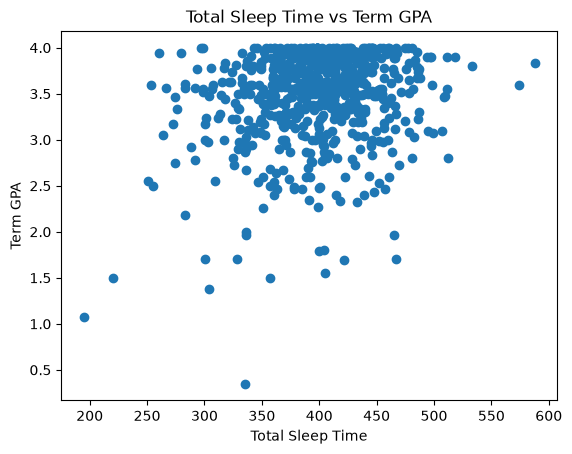

In [27]:
plt.scatter(df["TotalSleepTime"], df["term_gpa"])
plt.title('Total Sleep Time vs Term GPA')
plt.xlabel('Total Sleep Time')
plt.ylabel('Term GPA')
plt.show()